In [7]:
# Importação do DataFrame através do módulo de limpeza 'data_cleaning' em ./src
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_cleaning import data_cleaning
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/data.csv")
df = data_cleaning(df)

# Análise 1 - TOP 10 Produtos mais vendidos

    

In [13]:
# Agrupamento das colunas 'Nome_Produto' e 'Faturamento', na qual pega os 10 valores com maiores somas de faturamento
top_10_products = df.groupby('Nome_Produto')['Faturamento'].sum().sort_values(ascending= False).head(n=10)

# Exibição de Resultado
top_10_products

Nome_Produto
Laptop Gamer         1987500.00
Placa de Vídeo       1476000.00
Monitor Ultrawide     868000.00
Cadeira Gamer         308400.00
Headset 7.1           264000.00
SSD 1TB               220200.00
Teclado Mecânico      193769.92
Mouse Vertical         50127.86
Name: Faturamento, dtype: float64

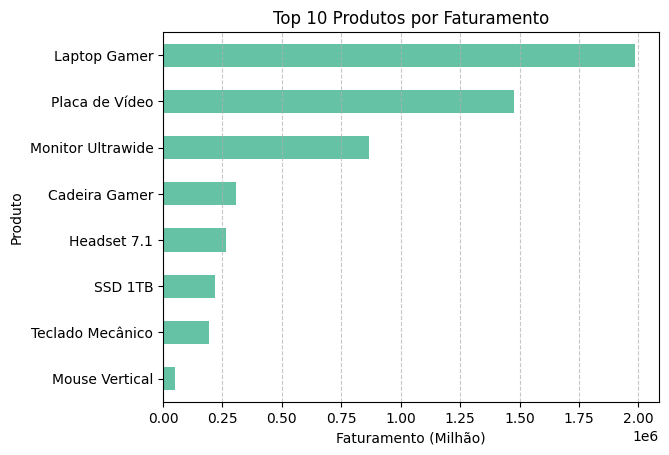

In [30]:
# Exibição gráfica
top_10_products.plot(
    kind='barh',
    colormap='Set2'
    )

plt.title("Top 10 Produtos por Faturamento")
plt.xlabel("Faturamento (Milhão)")
plt.ylabel("Produto")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()  # maior no topo

plt.show()

# Análise 2 - Faturamento Mensal

In [31]:
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Tipo_Entrega
0,1000,2026-01-01 22:00:00,Headset 7.1,Acessórios,800.00,5,130,Curitiba,PR,4000.00,Normal
1,1001,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,502.86,7,129,São Paulo,SP,3520.02,Rápida
2,1002,2026-01-01 09:00:00,Cadeira Gamer,Móveis,1200.00,6,107,Porto Alegre,RS,7200.00,Normal
3,1003,2026-01-01 07:00:00,Headset 7.1,Acessórios,800.00,5,145,Belo Horizonte,MG,4000.00,Rápida
4,1004,2026-01-01 22:00:00,Headset 7.1,Acessórios,800.00,4,106,Rio de Janeiro,RJ,3200.00,Rápida


In [32]:
# Criação da coluna mês para facilitar agrupamento mensal
df['Mes'] = df['Data_Pedido'].dt.to_period('M')

# Exibição da nova coluna
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Tipo_Entrega,Mes
0,1000,2026-01-01 22:00:00,Headset 7.1,Acessórios,800.00,5,130,Curitiba,PR,4000.00,Normal,2026-01
1,1001,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,502.86,7,129,São Paulo,SP,3520.02,Rápida,2026-01
2,1002,2026-01-01 09:00:00,Cadeira Gamer,Móveis,1200.00,6,107,Porto Alegre,RS,7200.00,Normal,2026-01
3,1003,2026-01-01 07:00:00,Headset 7.1,Acessórios,800.00,5,145,Belo Horizonte,MG,4000.00,Rápida,2026-01
4,1004,2026-01-01 22:00:00,Headset 7.1,Acessórios,800.00,4,106,Rio de Janeiro,RJ,3200.00,Rápida,2026-01


In [34]:
# Agrupamento por mês e soma do faturamento
faturamento_mensal = df.groupby('Mes')['Faturamento'].sum()

faturamento_mensal

Mes
2026-01    1392035.05
2026-02    1422939.42
2026-03    1066483.02
2026-04    1486540.29
Freq: M, Name: Faturamento, dtype: float64

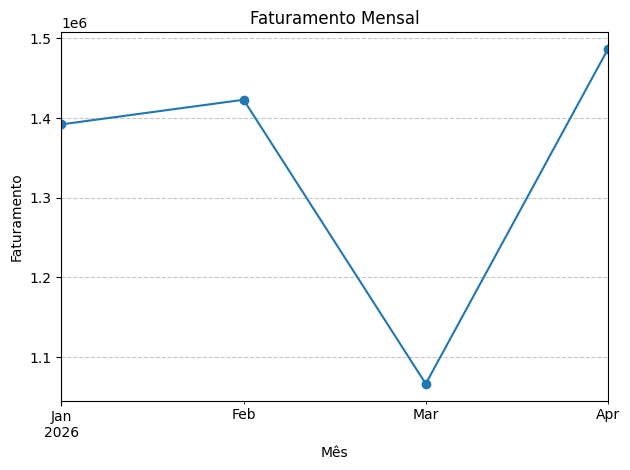

In [37]:
# Exibição gráfica
ax = faturamento_mensal.plot(kind='line', marker='o')

plt.title("Faturamento Mensal")
plt.xlabel("Mês")
plt.ylabel("Faturamento")

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Análise 3 - Vendas por Estado

In [ ]:
# Agrupamento de estado com faturamento
faturamento_estado = df.groupby('Estado')['Faturamento'].sum().sort_values(ascending=False)

# Realizando formatação de valores para 2 casas decimais
faturamento_estado.map('R$ {:,.2f}'.format)

Estado
RJ    R$ 826,266.97
PR    R$ 792,039.66
BA    R$ 787,586.29
SP    R$ 781,122.48
RS    R$ 766,092.10
CE    R$ 741,487.66
MG    R$ 673,402.62
Name: Faturamento, dtype: str

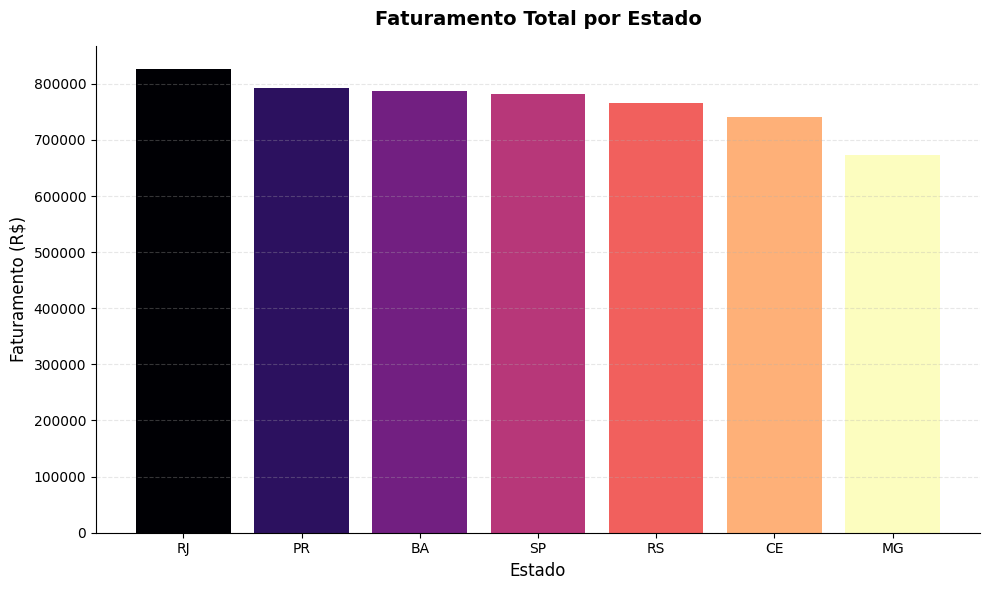

In [10]:
# Exibição gráfica

# Definindo o tamanho da figura
plt.figure(figsize=(10, 6))

# Criando uma lista de cores baseada em um mapa de cores (ex: 'viridis', 'plasma' ou 'tab10')
# O 'tab10' é ótimo para categorias distintas
cores = plt.cm.magma(np.linspace(0, 1, len(faturamento_estado)))

# Criando o gráfico de barras com cores variadas
plt.bar(faturamento_estado.index, faturamento_estado.values, color=cores)

# Adicionando títulos e rótulos
plt.title('Faturamento Total por Estado', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xlabel('Estado', fontsize=12)

# Melhorando a estética: removendo as bordas desnecessárias (spines)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Ajustando o formato do eixo Y para não aparecer em notação científica
plt.ticklabel_format(style='plain', axis='y')

# Adicionando grid suave apenas no eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Análise 4 - Faturamento por categoria

In [13]:
# Agrupamento por categoria com faturamento
faturamento_categoria = df.groupby('Categoria')['Faturamento'].sum().sort_values(ascending=False)

# Formatação para valores monetários
faturamento_categoria.map('R$ {:,.2f}'.format)

Categoria
Eletrônicos    R$ 2,855,500.00
Hardware       R$ 1,696,200.00
Acessórios       R$ 507,897.78
Móveis           R$ 308,400.00
Name: Faturamento, dtype: str

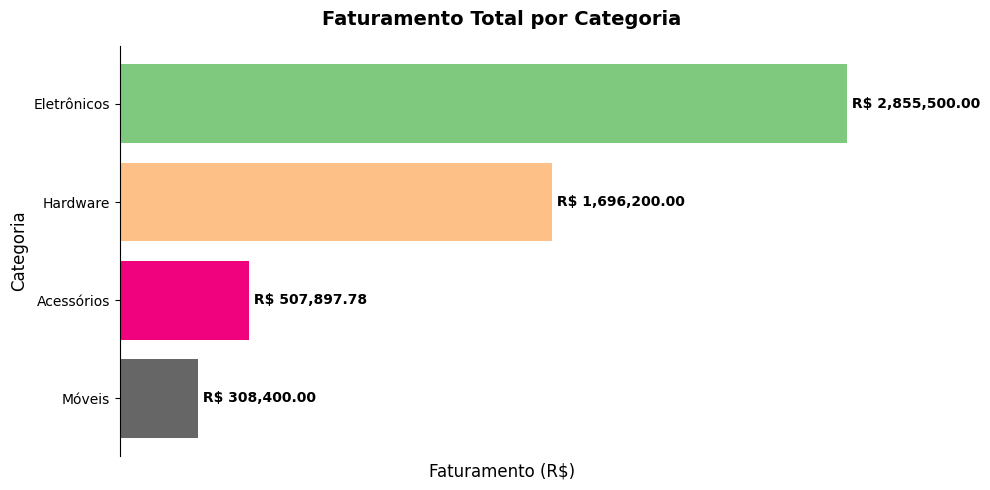

In [12]:
# Exibição gráfica

# Definindo o tamanho da figura
plt.figure(figsize=(10, 5))

# Criando as cores (usando o mapa 'Accent' para um visual moderno e colorido)
cores = plt.cm.Accent(np.linspace(0, 1, len(faturamento_categoria)))

# Criando o gráfico de barras HORIZONTAIS
# Note que usamos faturamento_categoria (numérica) e invertemos a ordem para a maior ficar no topo
grafico = plt.barh(faturamento_categoria.index[::-1], faturamento_categoria.values[::-1], color=cores[::-1])

# Adicionando títulos e rótulos
plt.title('Faturamento Total por Categoria', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faturamento (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

# Adicionando os valores exatos ao lado de cada barra
for i, v in enumerate(faturamento_categoria.values[::-1]):
    plt.text(v, i, f' R$ {v:,.2f}', va='center', fontsize=10, fontweight='bold')

# Estética: removendo bordas e o eixo X (já que temos os valores nas barras)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.xticks([]) # Remove os números do eixo X para não poluir

plt.tight_layout()
plt.show()